# 주의
- 모든 코드는 위의 섹션부터 순서대로 실행해야 정상 작동합니다.

In [6]:
# 환경 설정
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import KNNImputer

In [7]:
# 데이터셋을 불러와 head(), info(), describe() 결과를 출력
# 반드시 data/ 경로에 'heart_disease.csv' 파일이 존재해야 합니다.
# 없는 경우에는 다음을 실행해 생성: python data/data.py

# 파일 불러오기
heart_disease_df = pd.read_csv('../data/heart_disease.csv')

# head()
print(heart_disease_df.head())

# info()
print(heart_disease_df.info())

# describe()
print(heart_disease_df.describe())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  target  
0  0.0   6.0       0  
1  3.0   3.0       1  
2  2.0   7.0       1  
3  0.0   3.0       0  
4  0.0   3.0       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64

In [8]:
# 타깃 클래스 분포 출력
print(heart_disease_df['target'].value_counts(normalize=True))

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


# 타깃 클래스 분포가 평가 지표 선택에 미치는 영향
- 타깃 클래스는 0(정상)과 1(심장병)으로 분류되며, 그 분포는 0이 약 0.54, 1이 약 0.46으로 측정되었다. 정상과 심장병 비율이 각각 50%에 가까워 적절히 균형 잡혀 있어 모델 학습 시 데이터 쏠림 현상이 발생하지 않아 정확도를 신뢰할 수 있다.
- 심장병 진단이라는 목적상 실제 심장병 환자를 정상으로 잘못 예측(False Negative)했을 때 환자가 매우 위험할 수 있으므로, 최종적으로 모델을 평가할 때는 재현율을 평가 지표로 함께 고려해야 한다.

[열별 결측치 확인]
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

[전체 결측치 확인]
전체 결측치 개수:  6

[연속형 피처의 box plot 출력]


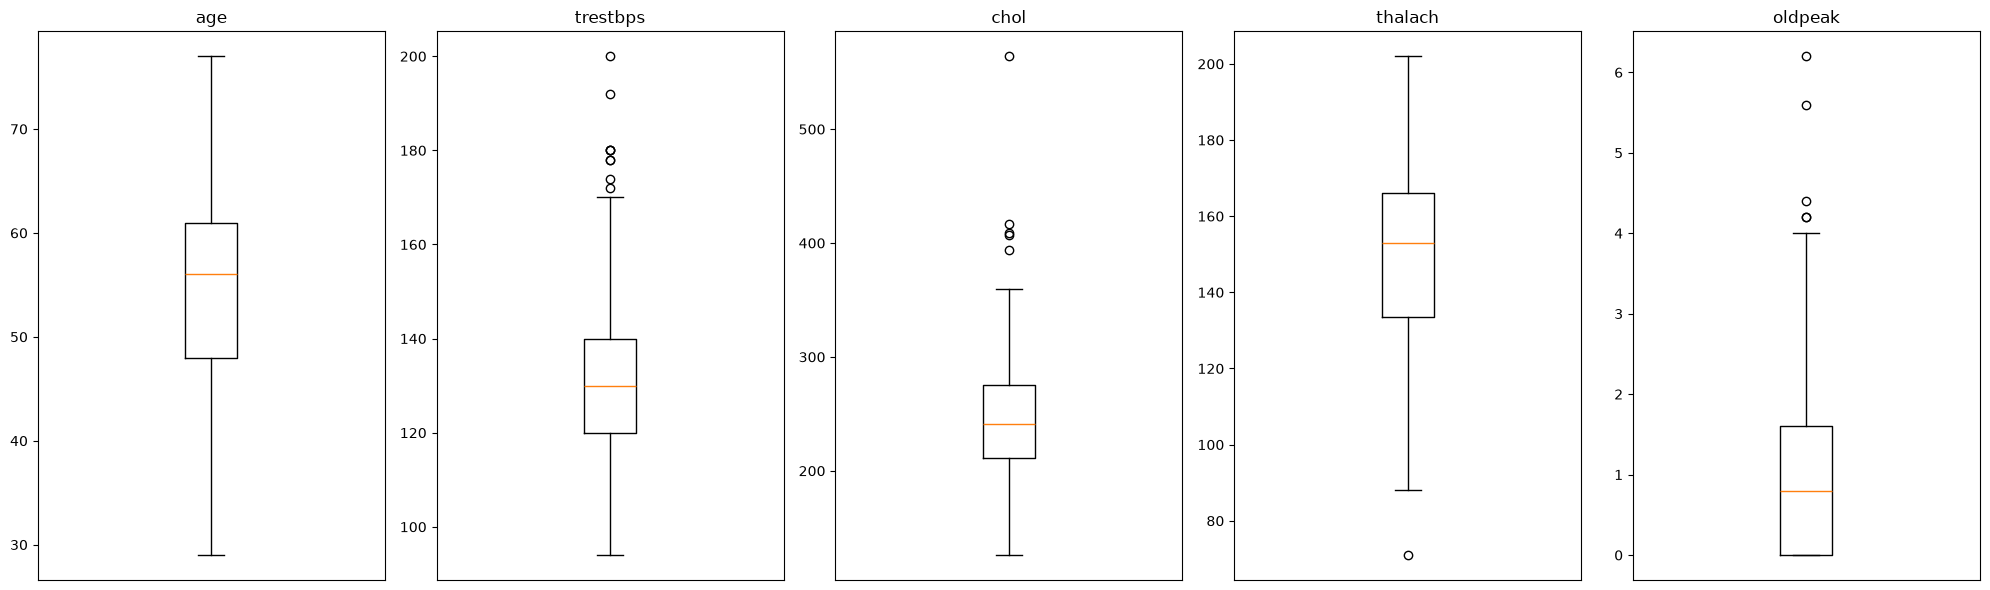


[IQR 확인]
[age 피처]
Q1: 48.0, Q3: 61.0, IQR: 13.0
이상치 개수: 0

[trestbps 피처]
Q1: 120.0, Q3: 140.0, IQR: 20.0
이상치 개수: 9

[chol 피처]
Q1: 211.0, Q3: 275.0, IQR: 64.0
이상치 개수: 5

[thalach 피처]
Q1: 133.5, Q3: 166.0, IQR: 32.5
이상치 개수: 1

[oldpeak 피처]
Q1: 0.0, Q3: 1.6, IQR: 1.6
이상치 개수: 5



C:\Users\로컬\AppData\Local\Temp\ipykernel_11872\423276759.py:42: FutureWarning: Operation between Series with different indexes that are not of numpy boolean or object dtype will no longer return a numpy boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  outliers = data[(data < lower)] | (data[(data > upper)])
C:\Users\로컬\AppData\Local\Temp\ipykernel_11872\423276759.py:42: FutureWarning: Operation between Series with different indexes that are not of numpy boolean or object dtype will no longer return a numpy boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  outliers = data[(data < lower)] | (data[(data > upper)])
C:\Users\로컬\AppData\Local\Temp\ipykernel_11872\423276759.py:42: FutureWarning: Operation between Series with different indexes that are not of numpy boolean or object dtype will no longer return a numpy boolean result in a future version. Cast both Series to object type to ma

In [9]:
# 결측값(열별/전체)과 이상치(boxplot + IQR)를 최소한 연속성 특성에 대해 탐지

# 열별 결측치 확인
print("[열별 결측치 확인]")
print(heart_disease_df.isnull().sum())

# 전체 결측치 확인
print("\n[전체 결측치 확인]")
print('전체 결측치 개수: ', heart_disease_df.isnull().sum().sum())

# 연속형 특성에 대한 이상치 탐지
# 'age', 'trestbps', 'chol', 'thalach', 'oldpeak'가 해당
# box plot + IQR을 통해 확인
print("\n[연속형 피처의 box plot 출력]")
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# 그래프 배치
fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, feature in enumerate(features):
    axes[i].boxplot(heart_disease_df[feature].dropna())
    axes[i].set_title(feature)
    axes[i].set_xticks([]) # x축 제거
    
plt.tight_layout()
plt.show()

# IQR로 피처별 이상치 개수 확인
print("\n[IQR 확인]")

for feature in features:
    data = heart_disease_df[feature].dropna()
    
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower)] | (data[(data > upper)])
    
    print(f"[{feature} 피처]")
    print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"이상치 개수: {len(outliers)}\n")

In [ ]:
# 결측값, 이상치, 빈 컬럼, 중복을 처리하는 전처리 파이프라인 구성
# 새 데이터에 재적용 가능한 함수로 구현, 실제로는 src/preprocessing.py을 통해 모듈 형태로 사용

# 결측치 처리 함수 (KNN 대치)
def impute_missing_values(train_df, test_df=None):
    imputer = KNNImputer(n_neighbors=5)
    train_imputed = pd.DataFrame(imputer.fit_transform(train_df), columns=train_df.columns)
    
    if test_df is not None:
        test_imputed = pd.DataFrame(imputer.fit_transform(test_df), columns=test_df.columns)
        return train_imputed, test_imputed
    
    return train_imputed

# 이상치 처리 함수 (IQR 클램핑): 이상치는 최소/최대치로 제한됨
def IQRClamp(df, bounds=None):
    df_clamped = df.copy()
    result_bounds = {}
    
    # 숫자형 열만 사용
    numeric_cols = df_clamped.select_dtypes(include=[np.number]).columns
    
    # 각 열의 IQR 범위 계산
    for col in numeric_cols:
        # 입력된 bounds가 없을 때는 직접 계산 (None)
        if bounds is None:
            Q1 = df_clamped[col].quantile(0.25)
            Q3 = df_clamped[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            result_bounds[col] = (lower, upper)
        # 입력된 bounds가 있을 때는 그걸 사용
        else:
            lower, upper = bounds.get(col, (-np.inf, np.inf)) # bounds 없는 열은 제한 없음
        
    # 각 열을 각자의 IQR 범위로 클램핑
    df_clamped[col] = df_clamped[col].clip(lower=lower, upper=upper)
    
    if bounds is None:
        return df_clamped, result_bounds
    else:
        return df_clamped

# 빈 열 및 중복 행 제거
def clean_data(df):
    df_cleaned = df.dropna(axis=1, how='all')
    df_cleaned = df_cleaned.drop_duplicates()
    return df_cleaned

### 파이프라인 작동 검증
# 행 또는 열이 제거되어 데이터의 형태가 변하는 전처리
df_cleaned = clean_data(heart_disease_df)

# 독립 변수(X)와 종속 변수(y) 분리
X = df_cleaned.drop(columns=['target'])
y = df_cleaned['target']

X_clamped, bounds = IQRClamp(X)
X_final = impute_missing_values(X_clamped)

print(f"최종 X 데이터: {X_final.shape}")
print(f"bounds = {bounds}")
print(f"결측치 개수: {X_final.isnull().sum().sum()}")

최종 X 데이터: (303, 13)
bounds = {'age': (np.float64(28.5), np.float64(80.5)), 'sex': (np.float64(-1.5), np.float64(2.5)), 'cp': (np.float64(1.5), np.float64(5.5)), 'trestbps': (np.float64(90.0), np.float64(170.0)), 'chol': (np.float64(115.0), np.float64(371.0)), 'fbs': (np.float64(0.0), np.float64(0.0)), 'restecg': (np.float64(-3.0), np.float64(5.0)), 'thalach': (np.float64(84.75), np.float64(214.75)), 'exang': (np.float64(-1.5), np.float64(2.5)), 'oldpeak': (np.float64(-2.4000000000000004), np.float64(4.0)), 'slope': (np.float64(-0.5), np.float64(3.5)), 'ca': (np.float64(-1.5), np.float64(2.5)), 'thal': (np.float64(-3.0), np.float64(13.0))}
결측치 개수: 0


# EDA가 무엇을 알려주었는가?
- 사용한 데이터셋은 총 303개의 행과 14개의 열로 이루어져 있다.
- 그중 결측치는 'ca', 'thal' 피처에 걸쳐 6개로 소량 존재한다.
- 타깃 클래스 분포는 약 54(정상):46(심장병)으로 균형 잡혀 있어 데이터 불균형 문제는 없을 것으로 보인다.
- 연속형 피처인 'age', 'trestbps', 'chol', 'thalach', 'oldpeak'에 IQR 범위를 벗어나는 이상치가 각각 0, 9, 5, 1, 5개로 다수 존재한다.

# 그에 따라 전처리에서 무엇을 어떻게 바꾸었는가?
1. 결측치 처리
- 과제 문서에서 "컬럼별로 삭제 vs. 평균/중앙값/KNN 대치를 정당화"라고 명시하고 있어 이를 바탕으로 정리한다.
- 본 데이터셋에서 결측치가 있는 컬럼은 'ca'와 'thal'이며, 결측치는 매우 소량이므로 컬럼을 제거하는 것은 그 효용성에 비해 정보 손실이 매우 크다.
- 또한 배포된 모델에 사용될 다른 데이터에서의 결측치는 현재 데이터셋과 다를 가능성이 크므로, 결측 행 또는 열의 삭제는 정보 손실에 의해 훈련 결과에 악영향을 줄 수 있다.
- 평균/중앙값 대치는 이상치에 의해 비정상적으로 크거나 작은 값이 도출되어 왜곡이 있을 수 있으므로, 다른 특성과의 관계를 통해 데이터의 성격을 보존하는 KNN 대치를 통해 모델의 학습을 더 안정적으로 만들었다.

2. 이상치 처리
- 심장병 진단이 목적인 본 시스템에서 이상치는 심장병에 대한 중요한 힌트가 될 수 있는 값이다. 따라서 IQR 규칙으로 검출한 이상치들을 그 IQR 범위 내로 제한(Clamp)하여 모델이 예측에 활용할 수 있도록 함과 동시에 과도한 왜곡을 일으키는 것을 방지한다.

3. 기타 전처리(데이터의 형태가 바뀌는 것을 고려하여 파이프라인 외부에서 먼저 진행하는 단계)
- 빈 컬럼 제거: 열 전체가 비어 있거나 같은 값만 존재하는 빈 컬럼은 학습에 아무런 도움이 되지 않지만 복잡도를 증가시키므로 제거한다.
- 중복 데이터(행) 제거: 모든 열이 같은 값을 갖는 중복된 행은 삭제한다.